# Training results plots (v4)

Load merged outputs from `merge_and_finalize.py` (notebook 02 v4 HPC run) and regenerate presentation figures.

**Inputs:** merged CSVs under `data/model_results_v4/`; optional cell metadata from `data/processed_no_prot_no_methyl/`.

In [ ]:
%pip install -q pandas numpy matplotlib seaborn scipy scikit-learn

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

RESULTS_DIR = Path("./data/model_results_v4")
PROCESSED_DIR = Path("./data/processed_no_prot_no_methyl")
PLOTS_DIR = Path("./Plots")

FIGURE_DIR = RESULTS_DIR / "figures"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(f"RESULTS_DIR  : {RESULTS_DIR.resolve()}")
print(f"PROCESSED_DIR: {PROCESSED_DIR.resolve()}")
print(f"PLOTS_DIR    : {PLOTS_DIR.resolve()}")

RESULTS_DIR  : /Users/abisolaajuwon/Documents/Developments/Multi-Omics-Mechanism-Modelling-AAC/data/model_results_v4
PROCESSED_DIR: /Users/abisolaajuwon/Documents/Developments/Multi-Omics-Mechanism-Modelling-AAC/data/processed_no_prot_no_methyl
PLOTS_DIR    : /Users/abisolaajuwon/Documents/Developments/Multi-Omics-Mechanism-Modelling-AAC/Plots


In [2]:
from typing import Optional

def load_csv(name: str, required: bool = True) -> Optional[pd.DataFrame]:
    path = RESULTS_DIR / name
    if not path.exists():
        msg = f"Missing: {path}"
        if required:
            raise FileNotFoundError(msg)
        print(msg)
        return None
    df = pd.read_csv(path)
    print(f"Loaded {name}: {df.shape}")
    return df


cv_metrics = load_csv("cv_metrics.csv")
cv_predictions = load_csv("cv_predictions.csv")
learned_weights = load_csv("learned_late_fusion_weights.csv", required=False)
top10 = load_csv("top10_model_strategy_summary.csv", required=False)
within_lineage_df = load_csv("within_lineage_metrics.csv", required=False)
within_comparison = load_csv("within_lineage_comparison.csv", required=False)

meta_path = PROCESSED_DIR / "cell_metadata.parquet"
cell_metadata = pd.read_parquet(meta_path) if meta_path.exists() else None
if cell_metadata is not None:
    if "ModelID" in cell_metadata.columns:
        cell_metadata = cell_metadata.set_index("ModelID")
    print(f"Loaded cell_metadata: {cell_metadata.shape}")
else:
    print(f"No cell metadata at {meta_path} — within-lineage plot uses precomputed CSV only")

print(f"\nCompounds in cv_metrics: {cv_metrics['compound'].nunique()}")

Loaded cv_metrics.csv: (93720, 12)
Loaded cv_predictions.csv: (8912552, 8)
Loaded learned_late_fusion_weights.csv: (12780, 7)
Loaded top10_model_strategy_summary.csv: (10, 9)
Loaded within_lineage_metrics.csv: (201968, 10)
Loaded within_lineage_comparison.csv: (32, 5)
Loaded cell_metadata: (574, 8)

Compounds in cv_metrics: 426


## 1. CV performance — Pearson r by strategy / model family

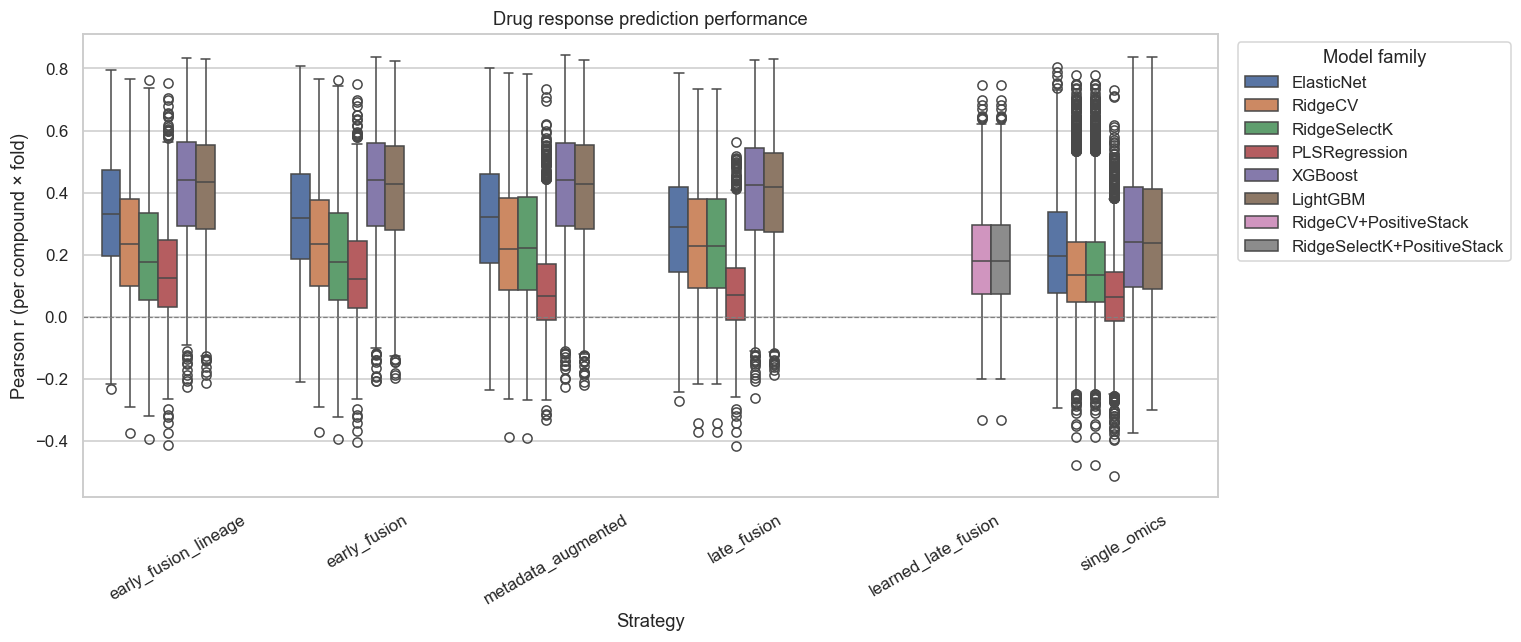

Saved: Plots/cv_pearson_by_strategy.png


In [4]:
TOP_N_STRATEGIES = 8
top_strategies = (
    cv_metrics.groupby("strategy")["pearson"]
    .mean().sort_values(ascending=False).head(TOP_N_STRATEGIES).index
)
plot_data = cv_metrics[cv_metrics["strategy"].isin(top_strategies)].copy()

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(
    data=plot_data, x="strategy", y="pearson", hue="model_family",
    order=list(top_strategies), ax=ax,
)
ax.set_xlabel("Strategy")
ax.set_ylabel("Pearson r (per compound × fold)")
ax.set_title("Drug response prediction performance")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.tick_params(axis="x", rotation=30)
plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left", title="Model family")
plt.tight_layout()

out = PLOTS_DIR / "cv_pearson_by_strategy.png"
fig.savefig(out, dpi=180, bbox_inches="tight")
fig.savefig(FIGURE_DIR / "cv_pearson_by_strategy.png", dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {out}")

## 2. Top 10 configs + best model summary

,rank,model_family,strategy,omics_layer,mean_pearson,mean_spearman,mean_r2,mean_rmse,n_folds
0,1,XGBoost,early_fusion,multiomics,0.4175,0.3700,0.1800,0.0855,2130
1,2,XGBoost,early_fusion_lineage,multiomics_plus_lineage,0.4174,0.3693,0.1798,0.0855,2130
2,3,XGBoost,metadata_augmented,expr_plus_lineage,0.4174,0.3694,0.1789,0.0856,2130
3,4,XGBoost,single_omics,expr,0.4163,0.3683,0.1778,0.0857,2130
4,5,LightGBM,early_fusion_lineage,multiomics_plus_lineage,0.4087,0.3615,0.1727,0.0860,2130
5,6,LightGBM,early_fusion,multiomics,0.4085,0.3612,0.1723,0.0861,2130
6,7,LightGBM,single_omics,expr,0.4054,0.3576,0.1690,0.0863,2130
7,8,LightGBM,metadata_augmented,expr_plus_lineage,0.4052,0.3579,0.1691,0.0863,2130
8,9,XGBoost,late_fusion,late_fusion(expr_mut_cnv),0.4016,0.3507,0.1397,0.0885,2130
9,10,LightGBM,late_fusion,late_fusion(expr_mut_cnv),0.3924,0.3418,0.1320,0.0889,2130



Best: XGBoost / early_fusion / multiomics (mean Pearson = 0.4175)


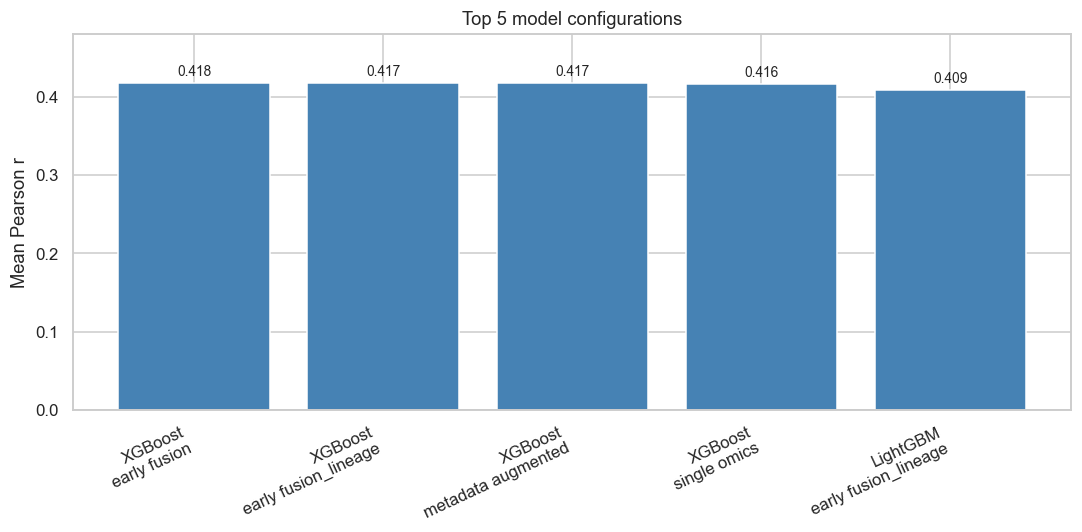

Saved: Plots/top5_model_configs.png


In [5]:
if top10 is None:
    config_summary = (
        cv_metrics
        .groupby(["model_family", "strategy", "omics_layer"], as_index=False)
        .agg(
            mean_pearson=("pearson", "mean"),
            mean_spearman=("spearman", "mean"),
            mean_r2=("r2", "mean"),
            mean_rmse=("rmse", "mean"),
            n_folds=("pearson", "count"),
        )
        .sort_values(["mean_pearson", "mean_spearman"], ascending=False)
        .reset_index(drop=True)
    )
    config_summary["rank"] = config_summary.index + 1
    top10 = config_summary.head(10)

display(
    top10[["rank", "model_family", "strategy", "omics_layer",
           "mean_pearson", "mean_spearman", "mean_r2", "mean_rmse", "n_folds"]]
    .round(4)
)

best = top10.iloc[0]
print(
    f"\nBest: {best['model_family']} / {best['strategy']} / {best['omics_layer']} "
    f"(mean Pearson = {best['mean_pearson']:.4f})"
)

# Bar chart: top 5 configs by mean Pearson r
top5 = top10.head(5).copy()
top5["label"] = (
    top5["model_family"] + "\n" + top5["strategy"].str.replace("_", " ", n=1)
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(top5["label"], top5["mean_pearson"], color="steelblue", edgecolor="white")
ax.set_ylabel("Mean Pearson r")
ax.set_title("Top 5 model configurations")
ax.set_ylim(0, top5["mean_pearson"].max() * 1.15)
for bar, val in zip(bars, top5["mean_pearson"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
out = PLOTS_DIR / "top5_model_configs.png"
fig.savefig(out, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {out}")

## 3. Predicted vs observed AAC (2 example drugs)

Uses the best-ranked config from the top-10 table. Picks one well-predicted and one poorly-predicted drug.

Prediction rows for best config: 202,558
Example drugs (best / worst Pearson): ['Cytarabine', 'BRD-K42260513']


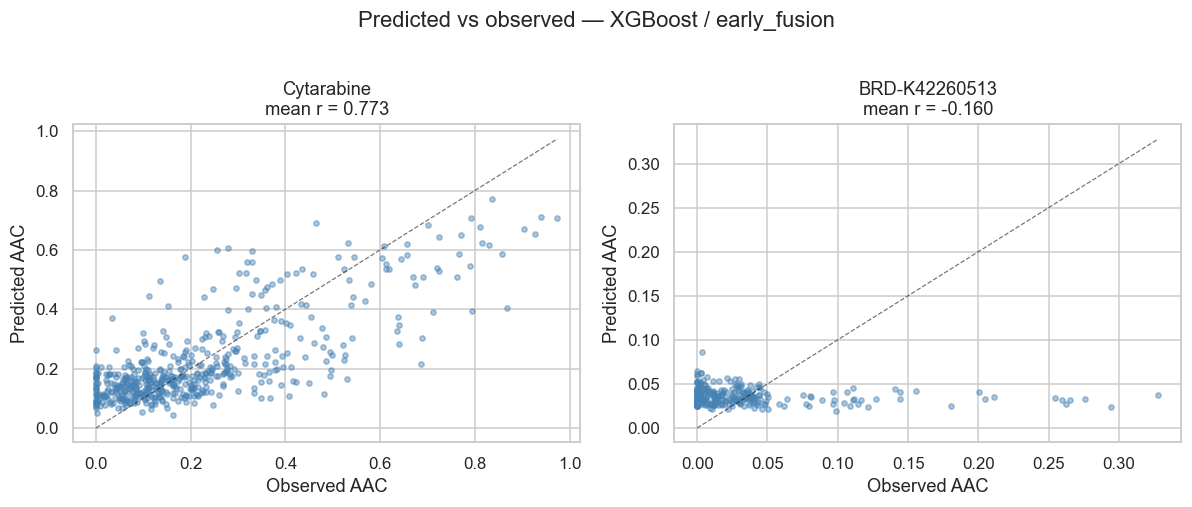

Saved: Plots/pred_vs_observed_examples.png


In [6]:
BEST_FAMILY = best["model_family"]
BEST_STRATEGY = best["strategy"]
BEST_LAYER = best["omics_layer"]

pred_mask = (
    (cv_predictions["model_family"] == BEST_FAMILY)
    & (cv_predictions["strategy"] == BEST_STRATEGY)
)
if "omics_layer" in cv_predictions.columns:
    pred_mask &= cv_predictions["omics_layer"] == BEST_LAYER

preds_best = cv_predictions.loc[pred_mask].copy()
print(f"Prediction rows for best config: {len(preds_best):,}")

drug_scores = (
    cv_metrics.loc[
        (cv_metrics["model_family"] == BEST_FAMILY)
        & (cv_metrics["strategy"] == BEST_STRATEGY)
        & (cv_metrics["omics_layer"] == BEST_LAYER)
    ]
    .groupby("compound")["pearson"].mean()
    .sort_values(ascending=False)
)

example_drugs = [drug_scores.index[0], drug_scores.index[-1]]
print(f"Example drugs (best / worst Pearson): {example_drugs}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, drug in zip(axes, example_drugs):
    d = preds_best[preds_best["compound"] == drug]
    ax.scatter(d["y_true"], d["y_pred"], alpha=0.45, s=12, color="steelblue")
    lims = [
        min(d["y_true"].min(), d["y_pred"].min()),
        max(d["y_true"].max(), d["y_pred"].max()),
    ]
    ax.plot(lims, lims, "k--", linewidth=0.8, alpha=0.6)
    r = drug_scores.get(drug, np.nan)
    ax.set_title(f"{drug}\nmean r = {r:.3f}")
    ax.set_xlabel("Observed AAC")
    ax.set_ylabel("Predicted AAC")

fig.suptitle(
    f"Predicted vs observed — {BEST_FAMILY} / {BEST_STRATEGY}",
    y=1.02,
)
plt.tight_layout()
out = PLOTS_DIR / "pred_vs_observed_examples.png"
fig.savefig(out, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {out}")

## 4. Learned late-fusion weights

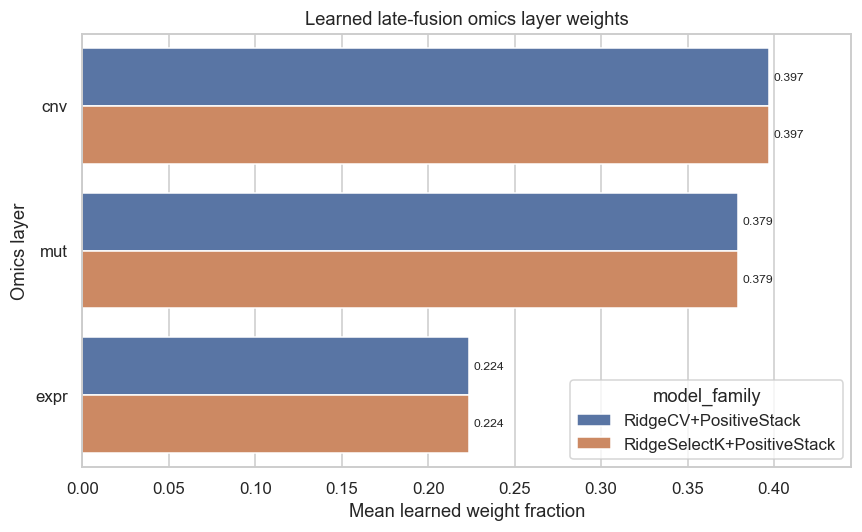

Saved: Plots/learned_late_fusion_weights.png


In [10]:
if learned_weights is None or learned_weights.empty:
    print("learned_late_fusion_weights.csv not found — skip this plot.")
else:
    weight_summary = (
        learned_weights
        .groupby(["model_family", "omics_layer"], as_index=False)["weight_fraction"]
        .mean()
        .sort_values(["model_family", "weight_fraction"], ascending=[True, False])
    )

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(
        data=weight_summary, x="weight_fraction", y="omics_layer",
        hue="model_family", ax=ax,
    )
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=3, fontsize=8)
    xmax = weight_summary["weight_fraction"].max()
    ax.set_xlim(0, xmax * 1.12)
    ax.set_xlabel("Mean learned weight fraction")
    ax.set_ylabel("Omics layer")
    ax.set_title("Learned late-fusion omics layer weights")
    plt.tight_layout()

    out = PLOTS_DIR / "learned_late_fusion_weights.png"
    fig.savefig(out, dpi=180, bbox_inches="tight")
    fig.savefig(FIGURE_DIR / "learned_late_fusion_weights.png", dpi=180, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out}")

## 5. Within-lineage performance

Uses `within_lineage_metrics.csv` if present; otherwise skips the per-lineage boxplot.

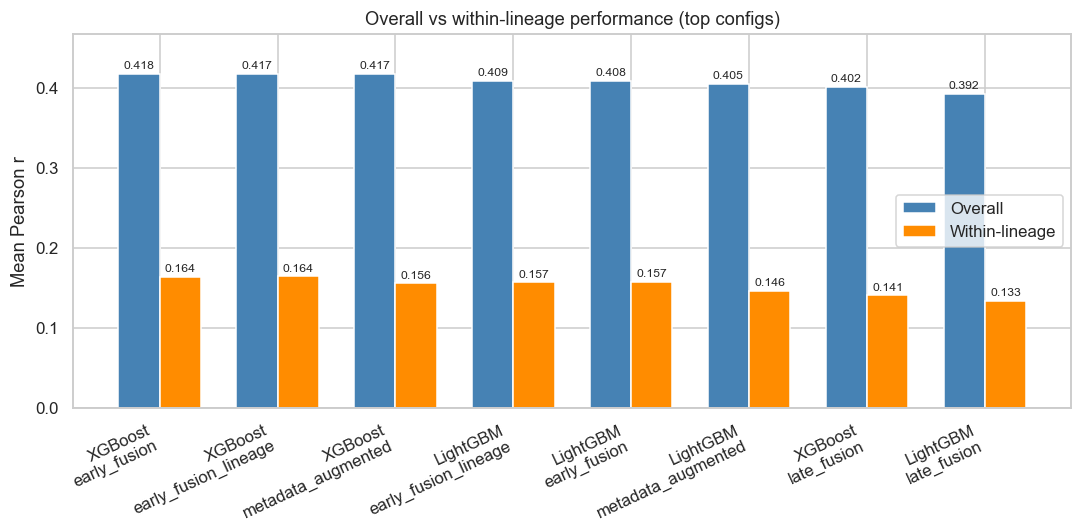

Saved: Plots/within_lineage_comparison.png


In [11]:
if within_comparison is not None and not within_comparison.empty:
    comp = within_comparison.copy()
    # Handle MultiIndex CSV from pandas (model_family, strategy as index columns)
    if "model_family" not in comp.columns:
        unnamed = [c for c in comp.columns if str(c).startswith("Unnamed")]
        if len(unnamed) >= 2:
            comp = comp.rename(columns={unnamed[0]: "model_family", unnamed[1]: "strategy"})
        elif comp.shape[1] >= 5:
            comp.columns = ["model_family", "strategy", "overall_pearson",
                            "within_lineage_pearson", "drop"][: comp.shape[1]]
    comp_top = comp.sort_values("overall_pearson", ascending=False).head(8)

    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(comp_top))
    width = 0.35
    bars_overall = ax.bar(
        x - width / 2, comp_top["overall_pearson"], width,
        label="Overall", color="steelblue",
    )
    bars_within = ax.bar(
        x + width / 2, comp_top["within_lineage_pearson"], width,
        label="Within-lineage", color="darkorange",
    )
    ymax = max(comp_top["overall_pearson"].max(), comp_top["within_lineage_pearson"].max())
    for bars in (bars_overall, bars_within):
        ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=8)
    ax.set_ylim(0, ymax * 1.12)
    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"{r.model_family}\n{r.strategy}" for r in comp_top.itertuples()],
        rotation=25, ha="right",
    )
    ax.set_ylabel("Mean Pearson r")
    ax.set_title("Overall vs within-lineage performance (top configs)")
    ax.legend()
    plt.tight_layout()
    out = PLOTS_DIR / "within_lineage_comparison.png"
    fig.savefig(out, dpi=180, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out}")
else:
    print("within_lineage_comparison.csv not found — skip comparison bar chart.")

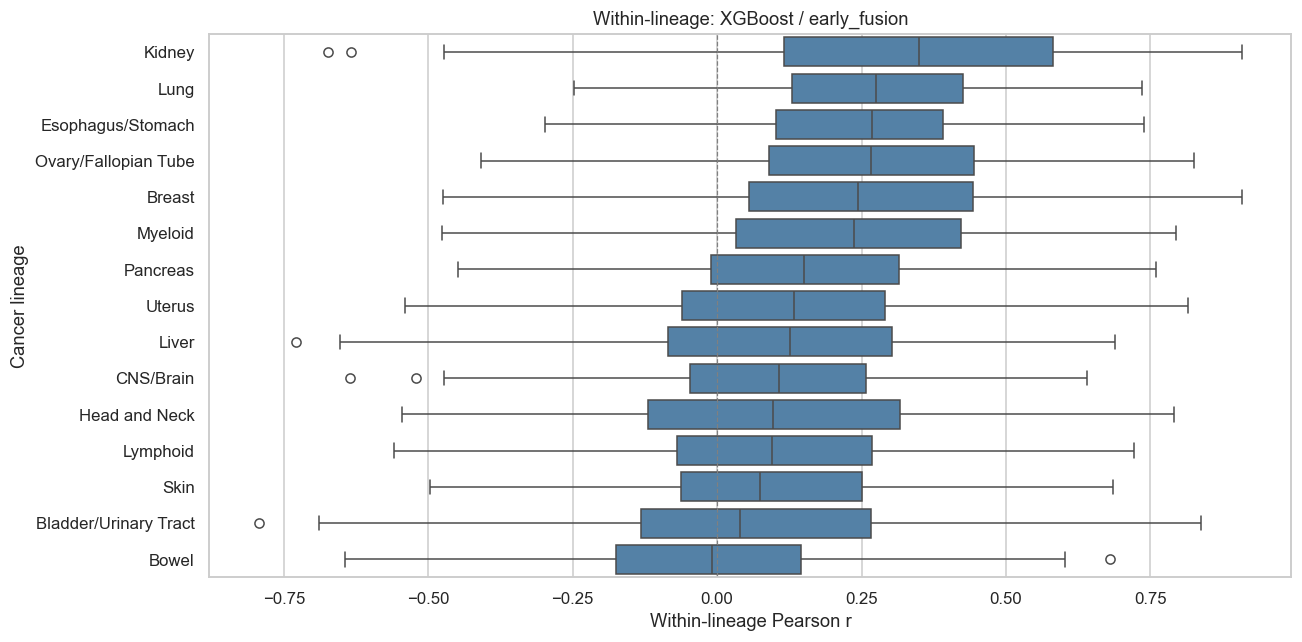

Saved: Plots/within_lineage_pearson.png


In [12]:
if within_lineage_df is None or within_lineage_df.empty:
    print("within_lineage_metrics.csv not found — skip per-lineage boxplot.")
else:
    wl_sub = within_lineage_df[
        (within_lineage_df["model_family"] == BEST_FAMILY)
        & (within_lineage_df["strategy"] == BEST_STRATEGY)
    ]
    if wl_sub.empty:
        best_combo = cv_metrics.groupby(["model_family", "strategy"])["pearson"].mean().idxmax()
        BEST_FAMILY, BEST_STRATEGY = best_combo
        wl_sub = within_lineage_df[
            (within_lineage_df["model_family"] == BEST_FAMILY)
            & (within_lineage_df["strategy"] == BEST_STRATEGY)
        ]

    top_lin = wl_sub.groupby("lineage")["pearson"].median().nlargest(15).index
    wl_plot = wl_sub[wl_sub["lineage"].isin(top_lin)]

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.boxplot(data=wl_plot, x="pearson", y="lineage", order=list(top_lin), ax=ax, color="steelblue")
    ax.set_xlabel("Within-lineage Pearson r")
    ax.set_ylabel("Cancer lineage")
    ax.set_title(f"Within-lineage: {BEST_FAMILY} / {BEST_STRATEGY}")
    ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)
    plt.tight_layout()

    out = PLOTS_DIR / "within_lineage_pearson.png"
    fig.savefig(out, dpi=180, bbox_inches="tight")
    fig.savefig(FIGURE_DIR / "within_lineage_pearson.png", dpi=180, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out}")

Figures are saved to `Plots/` and mirrored under `RESULTS_DIR/figures/`.